In [35]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [ ]:
# target_row = 180
target_row = 150
target_rows = [200, 180, 150]

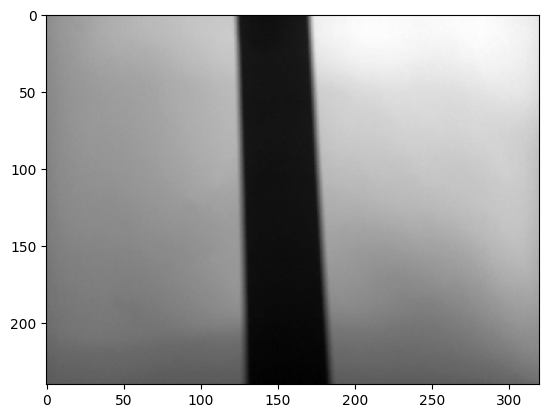

In [36]:
image = cv2.imread('line_1.jpg')
resized = cv2.resize(image, (320, 240))
gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
plt.imshow(gray, cmap="gray")

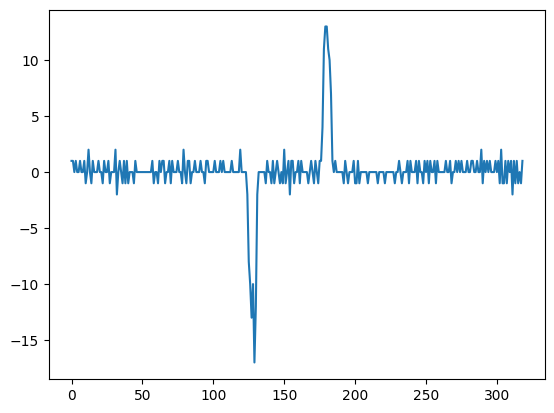

In [ ]:
row = gray[target_row].astype(np.int32)
diff = np.diff(row)
plt.plot(diff)

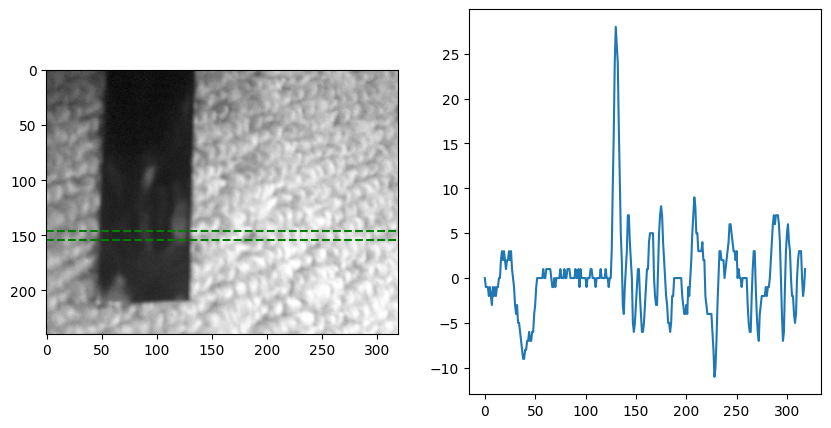

In [54]:
def plot_image_and_diff(img, diff):
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap="gray")
    # plot a horizontal line at 176 and 184
    plt.axhline(target_row - 4, color='green', linestyle='--')
    plt.axhline(target_row + 4, color='green', linestyle='--')
    plt.subplot(1, 2, 2)
    plt.plot(diff)
plot_image_and_diff(gray, diff)

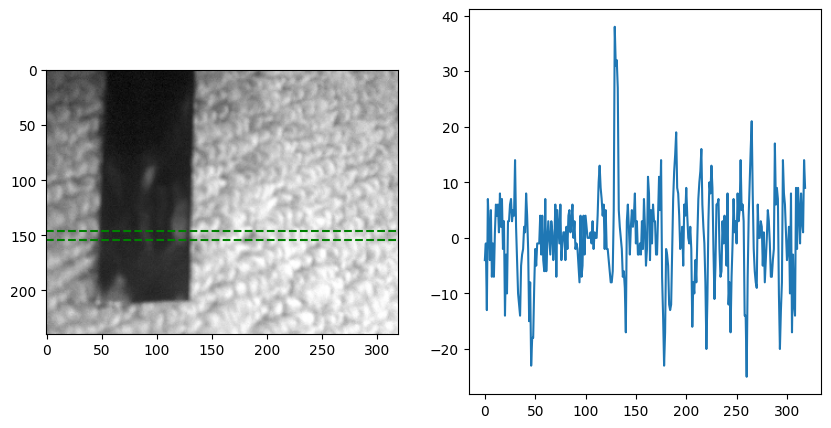

In [62]:
image = cv2.imread('carpet_line1.jpg')
resized = cv2.resize(image, (320, 240))
gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

row = gray[target_row].astype(np.int32)
diff = np.diff(row)

plot_image_and_diff(gray, diff)

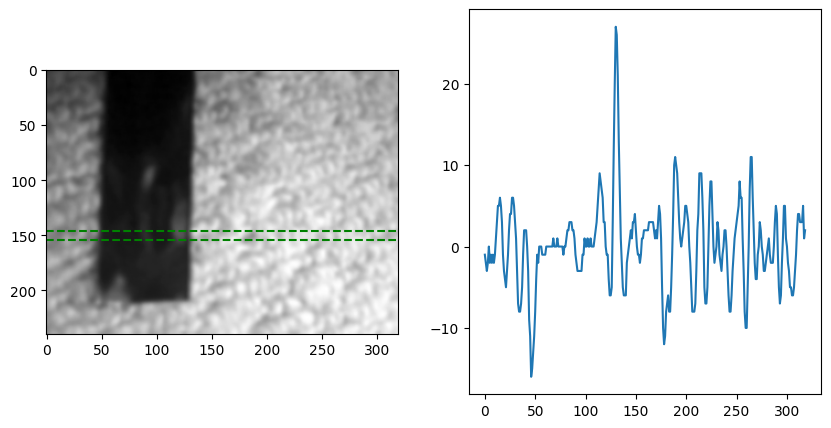

In [63]:
blurred = cv2.blur(gray, (5, 5), 0)
row = blurred[target_row].astype(np.int32)
diff = np.diff(row)
plot_image_and_diff(blurred, diff)

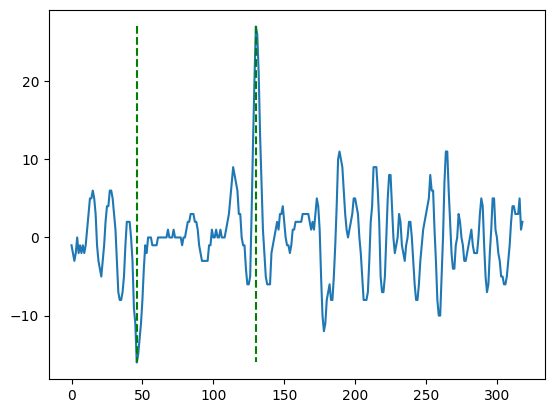

In [64]:
max_d = np.amax(diff)
min_d = np.amin(diff)
highest = np.where(diff == max_d)[0][0]
lowest = np.where(diff == min_d)[0][0]
plt.plot(diff)
plt.plot([lowest, lowest], [max_d, min_d], "g--")
plt.plot([highest, highest], [max_d, min_d], "g--")

middle = (highest + lowest) / 2
# plt.plot([middle, middle], [max_d, min_d], "r-")


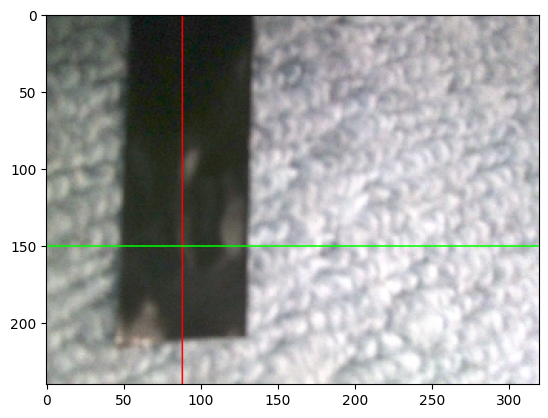

In [65]:
cv2.line(resized, (int(middle), 0), (int(middle), 240), (255, 0, 0))
cv2.line(resized, (0, target_row), (320, target_row), (0, 255, 0))
plt.imshow(resized)

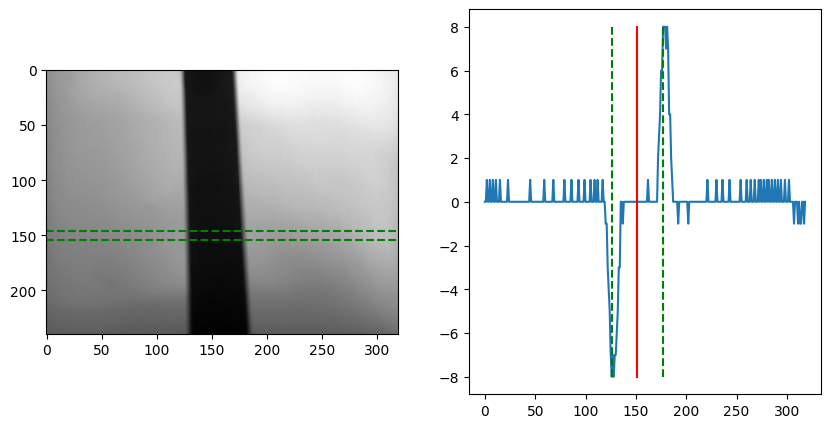

In [74]:
def plot_diffs(image_name):
    image = cv2.imread(image_name)
    resized = cv2.resize(image, (320, 240))
    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
    blurred = cv2.blur(gray, (10, 10), 0)
    row = blurred[target_row].astype(np.int32)
    diff = np.diff(row)
    plot_image_and_diff(gray, diff)

    max_d = np.amax(diff)
    min_d = np.amin(diff)
    highest = np.where(diff == max_d)[0][0]
    lowest = np.where(diff == min_d)[0][0]

    if max_d < 5 or min_d > -5:
        print("No line")
        return

    middle = (highest + lowest) / 2
    
    plt.plot([lowest, lowest], [max_d, min_d], "g--")
    plt.plot([highest, highest], [max_d, min_d], "g--")
    plt.plot([middle, middle], [max_d, min_d], "r-")
plot_diffs("line_1.jpg")

No line


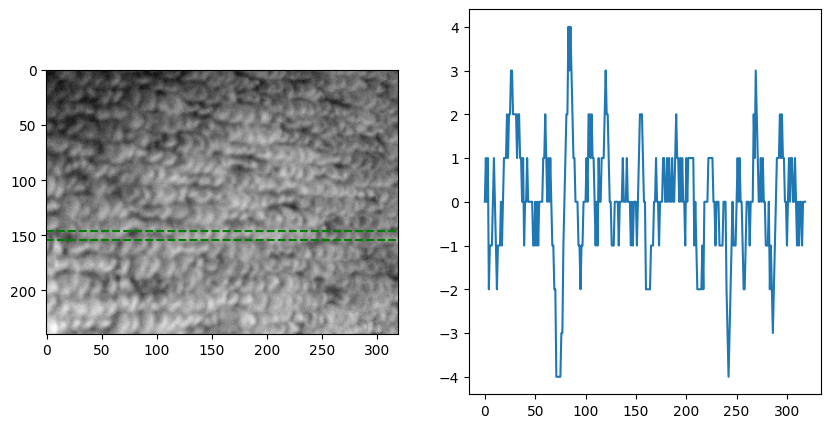

In [75]:
plot_diffs("empty_carpet.jpg")

No line


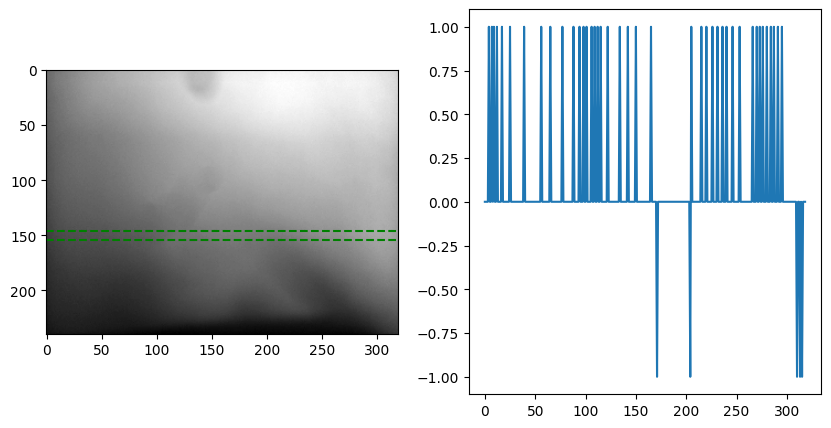

In [76]:
plot_diffs("empty_gray.jpg")

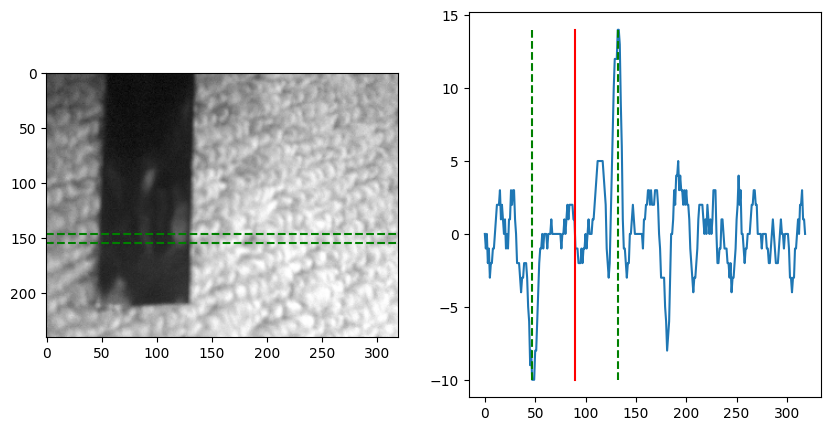

In [77]:
plot_diffs('carpet_line1.jpg')

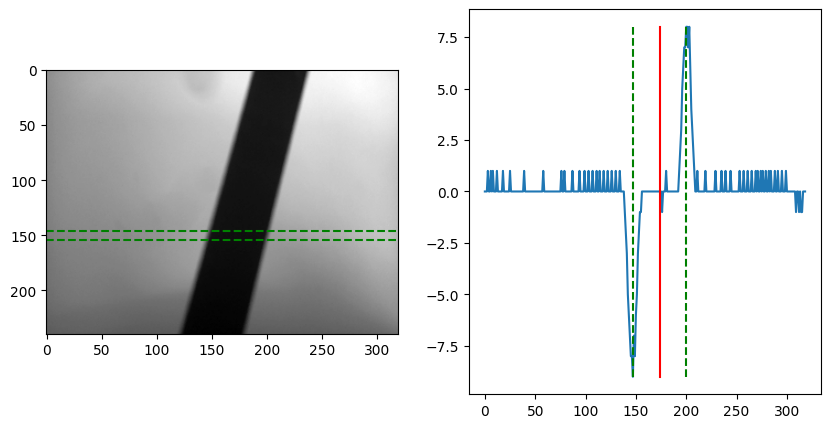

In [78]:
plot_diffs("line_2.jpg")

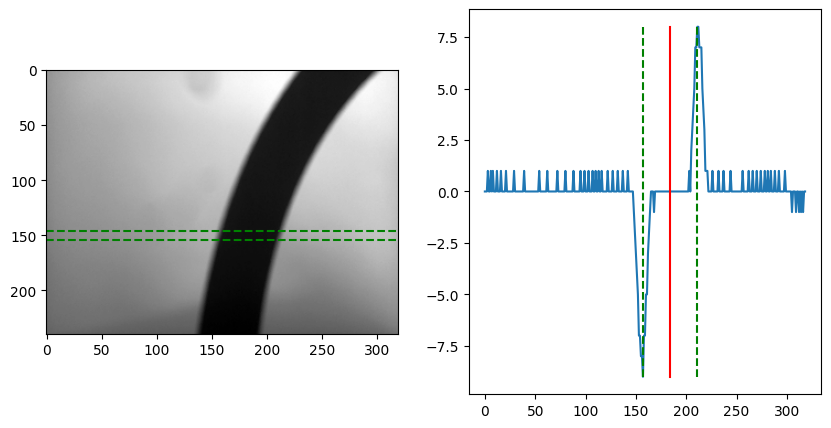

In [79]:
plot_diffs("line_3.jpg")

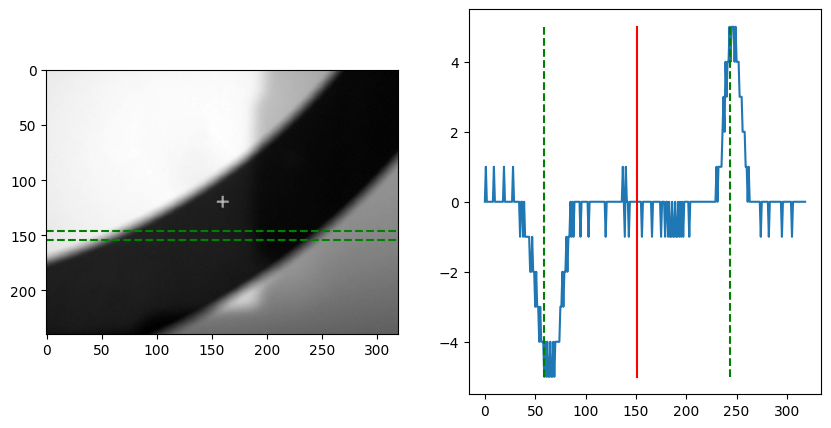

In [85]:
plot_diffs("line-it-missed.jpg")

No line


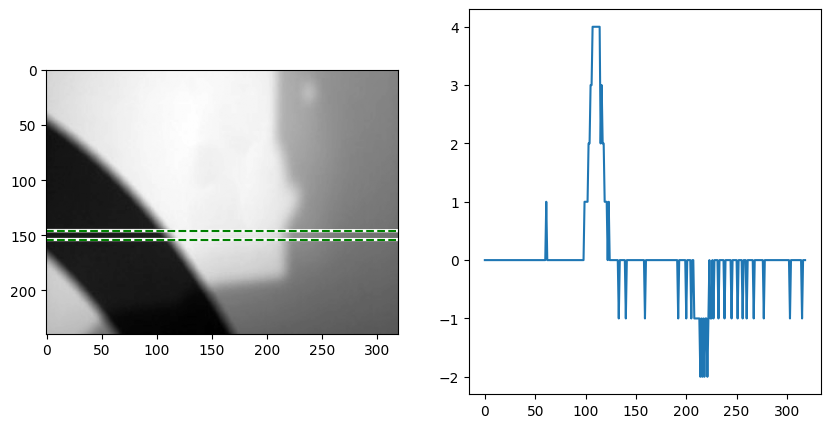

In [86]:
plot_diffs("Pasted image 20250810205801.jpg")